# Lab 6

You are tasked with evaluating card counting strategies for black jack. In order to do so, you will use object oriented programming to create a playable casino style black jack game where a computer dealer plays against $n$ computer players and possibily one human player. If you don't know the rules of blackjack or card counting, please google it. 

A few requirements:
* The game should utilize multiple 52-card decks. Typically the game is played with 6 decks.
* Players should have chips.
* Dealer's actions are predefined by rules of the game (typically hit on 16). 
* The players should be aware of all shown cards so that they can count cards.
* Each player could have a different strategy.
* The system should allow you to play large numbers of games, study the outcomes, and compare average winnings per hand rate for different strategies.

1. Begin by creating a classes to represent cards and decks. The deck should support more than one 52-card set. The deck should allow you to shuffle and draw cards. Include a "plastic" card, placed randomly in the deck. Later, when the plastic card is dealt, shuffle the cards before the next deal.

In [35]:
## Create standard deck with 52 cards where each card is represented as a tuple (suit,value)
suits = ["Clubs", "Diamonds", "Hearts", "Spades"]
values = list(range(2,11)) + ["Jack", "Queen", "King", "Ace"]

def make_deck():
    deck=list()
    for suit in suits:
        for value in values:
            deck.append((suit,value))
    return deck

## Gives ability to control debug messages in the game (often used DEBUG and INFO)
class base:
    SILENT=6
    DEBUG=1
    INFO=2
    WARNING=3
    ERROR=4
    CRITICAL=5

    def __init__(self, level=0):
        self.level=level
    def message(self,level,*args):
        if level >= self.level:
            print(*args)

## Defined the card suits and values using this class
## ShuffleCard indicates deck reshuffling
class Card(base):
    __suits = ["Clubs", "Diamonds", "Hearts", "Spades", "ShuffleCard"]
    __values = list(range(2,11)) + ["Jack", "Queen", "King", "Ace"]

    def __init__(self,suit,value=None):
        base.__init__(self)
        self.__suit = suit if suit in self.__suits else None
        self.__value = value if value in self.__values else None

        if self.__suit is None:
            self.message(self.ERROR, "Error, bad suit:",suit)

        if self.__value is None and self.__suit != "ShuffleCard":
            self.message(self.ERROR, "Error, bad value:",value)

    def value(self):
        return self.__value
    
    def suit(self):
        return self.__suit
    
    def numerical_value(self):
        if self.__value == "Ace":
            return 1
        elif self.__value in ["Jack", "Queen", "King"]:
            return 10
        else:
            return self.__value
    
    def shuffle_card(self):
        return self.__suit == "ShuffleCard"
    
    def __str__(self):
        if self.shuffle_card():
            return "Shuffle Card"
        else:
            return str(self.__value) + " of " + self.__suit
        
    __repr__ = __str__

This is from the example shown in lecture.

In [20]:
## Deck class made to support multiple decks and reshuffling
import random

class Deck(base):
    __suits = ["Clubs", "Diamonds", "Hearts", "Spades"]
    __values = list(range(2,11)) + ["Jack", "Queen", "King", "Ace"]

    def __init__(self, n_decks=6):
        base.__init__(self)
        self.__n_decks=n_decks

        self.__cards = list()

        for _ in range(self.__n_decks):
            self.__cards.extend(self.__make_deck())

        self.__cards.append(Card("ShuffleCard"))

    def __make_deck(self):
        deck=list()
        for suit in self.__suits:
            for value in self.__values:
                deck.append(Card(suit,value))
        return deck
    
    def shuffle(self):
        random.shuffle(self.__cards)

    def deal(self):
        if len(self.__cards)>0:
            return self.__cards.pop()
        else:
            for _ in range(self.__n_decks):
                self.__cards.extend(self.__make_deck())
            self.shuffle()
            return self.__cards.pop()

In [36]:
my_deck = Deck()
my_deck.shuffle()
[my_deck.deal() for _ in range(10)]

[Queen of Clubs,
 3 of Spades,
 Queen of Diamonds,
 4 of Hearts,
 5 of Diamonds,
 5 of Hearts,
 6 of Spades,
 Jack of Spades,
 10 of Spades,
 5 of Clubs]

In [37]:
def calc_hand_value_0(hand):
    return sum(map(lambda card: card.numerical_value(),hand))

In [38]:
## Determines what Ace should be depending on how close to 21 the hand value will be
def calc_hand_value(hand):
    card_values = list(map(lambda card: card.numerical_value(),hand))

    n_As = len(list(filter(lambda x: x==1, card_values)))

    hand_value = sum(card_values)

    if n_As==0:
        return hand_value
    
    Ace_as_one = hand_value
    Ace_as_eleven = hand_value+10

    if Ace_as_eleven<=21:
        return Ace_as_eleven
    else:
        return Ace_as_one

In [39]:
calc_hand_value([Card("Spades", 9), Card("Hearts", "Jack"), Card("Diamonds", "Ace")])

20

In [40]:
calc_hand_value([Card("Spades", 10), Card("Diamonds", "Ace")])

21

All of this was from the lecture example

2. Now design your game on a UML diagram. You may want to create classes to represent, players, a hand, and/or the game. As you work through the lab, update your UML diagram. At the end of the lab, submit your diagram (as pdf file) along with your notebook. 

3. Begin with implementing the skeleton (ie define data members and methods/functions, but do not code the logic) of the classes in your UML diagram.

4. Complete the implementation by coding the logic of all functions. For now, just implement the dealer player and human player.

In [41]:
## PlayerBase class keeps track of name, chips, and provides methods of changing chip counts. All players inherit from this class.
class PlayerBase(base):
    def __init__(self, name, n_chips):
        base.__init__(self)
        self.__name = name
        self.__n_chips=n_chips

    def name(self):
        return self.__name
    
    def chips(self):
        return self.__n_chips
    
    def pay(self,value=2):
        self.__n_chips+=value

    def deduct(self,value=2):
        self.__n_chips-=value

    def play_hand(self, down_card, up_cards, seen_cards):
        raise NotImplementedError
    
    def __str__(self):
        return self.__name + "("+ str(self.__n_chips) + ")"
    
    __repr__=__str__

## Dealer player hits below the threshold and console player allows user input.
class DealerPlayer(PlayerBase):
    def __init__(self,threshold=16):
        self.__threshold = threshold
        PlayerBase.__init__(self, "Mr.Dealer", 1000)

    def play_hand(self, down_card, up_cards, seen_cards):
        hand_value = calc_hand_value([down_card] + up_cards)
        return hand_value < self.__threshold
    
class ConsolePlayer(PlayerBase):
    def play_hand(self, down_card, up_cards, seen_cards):
        print("Down Card:", down_card)
        print("Up Cards:", up_cards)
        print("Seen Cards:", seen_cards)
        hit_str= input("Hit(Y/N):")
        return hit_str.upper()=="Y"
    
class Strategy_1_Player(PlayerBase):
    def play_hand(self, down_card, up_cards, seen_cards):
        return True

From the lecture

5.  Test. Demonstrate game play. For example, create a game of several dealer players and show that the game is functional through several rounds.

In [49]:
class Game(base):
    def __init__(self,n_decks=6):
        base.__init__(self,self.INFO)
        self.__n_decks = n_decks
        self.__players = list()
        self.__all_players = list()

        self.__shuffle = False

    def players(self):
        return self.__all_players
    
    def all_players(self):
        return self.__all_players
    
    def add_player(self,player):
        self.__players.append(player)
        self.__all_players.append(player)

    def deal_and_check_shuffle(self,deck):
        card = deck.deal()
        if card.shuffle_card():
            self.__shuffle=True
            card = deck.deal()
        return card
    
    def show_status(self, hands, seen_cards):
        self.message(self.INFO,"---------------------------------------------------------------")
        self.message(self.INFO, "Hands:", hands)
        self.message(self.INFO, "Seen Cards:", seen_cards)
        self.message(self.INFO, "*****************************************")
        self.message(self.INFO, "Players:")
        self.message(self.INFO, "*****************************************")
        for i,player in enumerate(self.__all_players):
            self.message(self.INFO,i,":",player)
        self.message(self.INFO,"---------------------------------------------------------------")
    
    def play_game(self,n_hands):
        self.add_player(DealerPlayer())

        deck = None
        self.__shuffle = False

        for i_hand in range(n_hands):
            self.__players = list(filter(lambda player: player.chips()>=2,self.__players))
            self.message(self.DEBUG, "n players, n all players", len(self.__players),len(self.__all_players))
            self.message(self.DEBUG, "Starting Hand:",i_hand,"/",n_hands)

            if deck is None or self.__shuffle:
                self.message(self.DEBUG, "Creating New Deck / Shuffling")
                deck = Deck()

                deck.shuffle()
                seen_cards = list()
                self.__shuffle = False

            hands = list()

            self.message(self.DEBUG, "Dealing Cards")
            for player_i,player in enumerate(self.__players):
                down_card = self.deal_and_check_shuffle(deck)
                up_cards = list()
                hands.append((down_card, up_cards))
                if player_i < len(self.__players)-1:
                    seen_cards.append(down_card)
            
            for (down_card, up_cards) in hands:
                up_cards.append(self.deal_and_check_shuffle(deck))
                seen_cards.append(up_cards[-1])

            self.show_status(hands,seen_cards)

            for player_i,((down_card, up_cards), player) in enumerate(zip(hands,self.__players)):
                self.message(self.DEBUG, "Asking Player", player_i,"to Play")
                self.message(self.DEBUG, "Player", player_i, "hand total:", calc_hand_value([down_card]+up_cards))
                hit = True
                this_hand_up_cards=list()
                while(hit):
                    hit = player.play_hand(down_card, up_cards, seen_cards)

                    if hit:
                        self.message(self.DEBUG,"Player",player_i,"Hit")
                        card = self.deal_and_check_shuffle(deck)
                        up_cards.append(card)
                        this_hand_up_cards.append(card)
                        hand_value = calc_hand_value([down_card] + up_cards)
                        self.message(self.DEBUG,"Hand Value",hand_value)
                        if hand_value < 21:
                            hit = True
                        else: 
                            hit = False
                            if hand_value > 21:
                                self.message(self.DEBUG,"Player",player_i,"Busted")
                            else:
                                self.message(self.DEBUG,"Player",player_i,"Got 21")  
                    else:
                        self.message(self.DEBUG,"Player",player_i,"Stay")  

                seen_cards.append(down_card)
                seen_cards.extend(this_hand_up_cards)
        
            hand_values = [calc_hand_value([hand[0]]+hand[1]) for hand in hands]

            self.message(self.DEBUG,"Hand Values",hand_values)

            if hand_values[-1]==21:
                self.message(self.DEBUG,"Dealer Got 21")
                for player_i,(hand_value,player) in enumerate(zip(hand_values[:-1], self.__players[:-1])):
                    if hand_value==21:
                        self.message(self.DEBUG,"Player", player_i,"Got 21. Paying 3 chips.")
                        player.pay(3)
                    else:
                        self.message(self.DEBUG,"Player", player_i,"Busted or dealer won. Deducting 2 chips.")
                        player.deduct(2)

            if hand_values[-1]>21:
                self.message(self.DEBUG,"Dealer Busted")
                for player_i,(hand_value,player) in enumerate(zip(hand_values[:-1], self.__players[:-1])):
                    if hand_value==21:
                        self.message(self.DEBUG,"Player", player_i,"Got 21. Paying 3 chips.")
                        player.pay(3)
                    elif hand_value>21:
                        self.message(self.DEBUG,"Player", player_i,"Busted. Deducting 2 chips.")
                        player.deduct(2)
                    else:
                        self.message(self.DEBUG,"Player", player_i,"Paying 2 chips.")
                        player.pay(2)
                
            if hand_values[-1]<21:
                self.message(self.DEBUG,"Dealer hand is:",hand_values[-1])
                for player_i,(hand_value,player) in enumerate(zip(hand_values[:-1], self.__players[:-1])):
                    if hand_value==21:
                        self.message(self.DEBUG,"Player", player_i,"Got 21. Paying 3 chips.")
                        player.pay(3)
                    elif hand_value>21:
                        self.message(self.DEBUG,"Player", player_i,"Busted. Deducting 2 chips.")
                        player.deduct(2)
                    elif hand_value > hand_values[-1]:
                        self.message(self.DEBUG,"Player", player_i,"hand was",hand_value, "versus Dealer hand",
                                hand_values[-1], "Paying 2 chips.")
                        player.pay(2)
                else:
                        self.message(self.DEBUG,"Player", player_i,"hand was",hand_value, "versus Dealer hand",
                                    hand_values[-1], "Deducting 2 chips.")
                        player.deduct(2)

Code from the lecture

In [50]:
my_game=Game()
my_game.level=Game.DEBUG

my_game.add_player(Strategy_1_Player("Dummy player",100))
my_game.add_player(ConsolePlayer("ME!",100))

my_game.play_game(2)

n players, n all players 3 3
Starting Hand: 0 / 2
Creating New Deck / Shuffling
Dealing Cards
---------------------------------------------------------------
Hands: [(6 of Spades, [5 of Clubs]), (King of Clubs, [7 of Spades]), (4 of Clubs, [Queen of Clubs])]
Seen Cards: [6 of Spades, King of Clubs, 5 of Clubs, 7 of Spades, Queen of Clubs]
*****************************************
Players:
*****************************************
0 : Dummy player(100)
1 : ME!(100)
2 : Mr.Dealer(1000)
---------------------------------------------------------------
Asking Player 0 to Play
Player 0 hand total: 11
Player 0 Hit
Hand Value 20
Player 0 Hit
Hand Value 23
Player 0 Busted
Asking Player 1 to Play
Player 1 hand total: 17
Down Card: King of Clubs
Up Cards: [7 of Spades]
Seen Cards: [6 of Spades, King of Clubs, 5 of Clubs, 7 of Spades, Queen of Clubs, 6 of Spades, 9 of Hearts, 3 of Clubs]
Player 1 Hit
Hand Value 26
Player 1 Busted
Asking Player 2 to Play
Player 2 hand total: 14
Player 2 Hit
Hand Val

6. Implement a new player with the following strategy:

    * Assign each card a value: 
        * Cards 2 to 6 are +1 
        * Cards 7 to 9 are 0 
        * Cards 10 through Ace are -1
    * Compute the sum of the values for all cards seen so far.
    * Hit if sum is very negative, stay if sum is very positive. Select a threshold for hit/stay, e.g. 0 or -2.  

In [78]:
## Strategy 1 Player always hits
class Strategy_1_Player(PlayerBase):
    def __init__(self, name, chips):
        super().__init__(name, chips)

    def play_hand(self, down_card, up_cards, seen_cards):
        return True

## Implements card counting strategy where program decides whether to hit or stay based on count of cards already seen.
class Strategy_2_Player(PlayerBase):
    def __init__(self, name, chips, threshold=0):
        super().__init__(name, chips)
        self.__threshold = threshold

    def card_count_value(self, card):
        val = card.value()
        if val in [2,3,4,5,6]:
            return 1
        elif val in [7,8,9]:
            return 0
        else:
            return -1

    def play_hand(self, down_card, up_cards, seen_cards):
        all_seen = [down_card] + up_cards + seen_cards
        count = sum(self.card_count_value(card) for card in all_seen)
        return count <= self.__threshold
## Dealer hits until reaching the fixed threshold (16)
class DealerLikePlayer(PlayerBase):
    def __init__(self, name, chips, threshold=16):
        super().__init__(name, chips)
        self.__threshold = threshold

    def play_hand(self, down_card, up_cards, seen_cards):
        hand_value = calc_hand_value([down_card] + up_cards)
        return hand_value < self.__threshold

Some of this code was with done with the help of AI and the lecture.

In [79]:
my_game = Game()
my_game.level = Game.SILENT

my_game.add_player(Strategy_2_Player("Counter", 100, threshold=0))
my_game.add_player(Strategy_1_Player("Dummy player", 100))
my_game.add_player(DealerLikePlayer("Dealer",100))

my_game.play_game(3)

[player.chips() for player in my_game.players()]

[94, 94, 104, 1000]

7. Create a test scenario where one player, using the above strategy, is playing with a dealer and 3 other players that follow the dealer's strategy. Each player starts with same number of chips. Play 50 rounds (or until the strategy player is out of money). Compute the strategy player's winnings. You may remove unnecessary printouts from your code (perhaps implement a verbose/quiet mode) to reduce the output.

In [80]:
## Set as a controlled experiment to evaluate the card counting strategy.
my_game = Game()
my_game.level = Game.SILENT  

starting_chips = 100

strategy_player = Strategy_2_Player("Counter", starting_chips, threshold=0)
my_game.add_player(strategy_player)

for i in range(3):
    my_game.add_player(DealerLikePlayer(f"Dealer_{i+1}", starting_chips))

dealer_player = DealerLikePlayer("Dealer", starting_chips)
my_game.add_player(dealer_player)

n_rounds = 50
for round_num in range(n_rounds):
    if strategy_player.chips() <= 0:
        print(f"Strategy player ran out of chips after {round_num} rounds.")
        break
    my_game.play_game(1) 

winnings = strategy_player.chips() - starting_chips
print(f"Strategy player's net winnings after {round_num+1} rounds: {winnings} chips")

Strategy player's net winnings after 50 rounds: -37 chips


Used AI to help as well as lecture

8. Create a loop that runs 100 games of 50 rounds, as setup in previous question, and store the strategy player's chips at the end of the game (aka "winnings") in a list. Histogram the winnings. What is the average winnings per round? What is the standard deviation. What is the probabilty of net winning or lossing after 50 rounds?


In [98]:
import numpy as np
import matplotlib.pyplot as plt
n_games = 100
n_rounds = 50
starting_chips = 100

strategy_winnings = []

for _ in range(n_games):
    game = Game()
    game.level = Game.SILENT
    
    strat_player = Strategy_2_Player("Counter", starting_chips, threshold=0)
    game.add_player(strat_player)
    for i in range(3): 
        game.add_player(DealerLikePlayer(f"DealerLike{i}", starting_chips))
    game.add_player(DealerLikePlayer("Dealer", 1000))  
    
    game.play_game(n_rounds)
    
    strategy_winnings.append(strat_player.chips())

Used AI and Lecture for this code

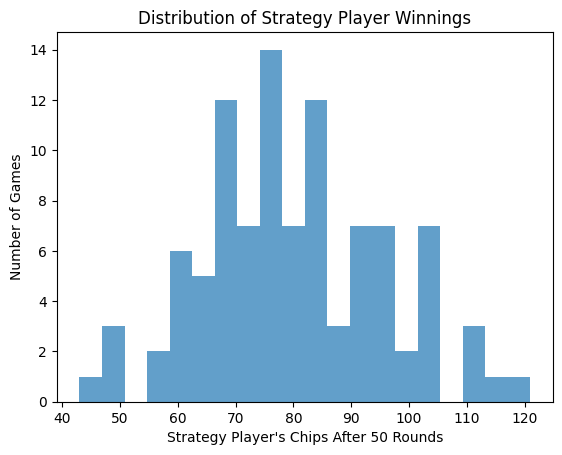

In [85]:
plt.hist(strategy_winnings, bins=20, alpha=0.7)
plt.xlabel("Strategy Player's Chips After 50 Rounds")
plt.ylabel("Number of Games")
plt.title("Distribution of Strategy Player Winnings")
plt.show()

In [96]:
winnings_array = np.array(strategy_winnings)
avg_winning = np.mean(winnings_array - starting_chips)  
std_dev = np.std(winnings_array - starting_chips)
prob_win = np.mean(winnings_array > starting_chips)
prob_loss = np.mean(winnings_array < starting_chips)

print("Average winnings/round:", avg_winning)
print("Std deviation:", std_dev)
print("Probability of net winning:", prob_win)
print("Probability of net losing:", prob_loss)

Average winnings/round: -21.84
Std deviation: 20.911585305758145
Probability of net winning: 0.14
Probability of net losing: 0.86


9. Repeat previous questions scanning the value of the threshold. Try at least 5 different threshold values. Can you find an optimal value?

In [88]:
thresholds = [-4, -2, 0, 2, 4]
n_games = 100
n_rounds = 50
starting_chips = 100

results_by_threshold = {}

for t in thresholds:
    final_winnings = []
    
    for _ in range(n_games):
        game = Game()
        game.level = Game.SILENT
        
        strat_player = Strategy_2_Player("Counter", starting_chips, threshold=t)
        game.add_player(strat_player)
        
        for i in range(3):
            game.add_player(DealerLikePlayer(f"DealerLike{i}", starting_chips))
        
        game.add_player(DealerLikePlayer("Dealer", 1000))
        
        game.play_game(n_rounds)
        
        final_winnings.append(strat_player.chips() - starting_chips)
    
    results_by_threshold[t] = np.array(final_winnings)

for t, vals in results_by_threshold.items():
    avg = np.mean(vals)
    std = np.std(vals)
    prob_win = np.mean(vals > 0)
    print(f"Threshold {t}: Avg = {avg:.2f}, Std = {std:.2f}, Prob Win = {prob_win:.2f}")

Threshold -4: Avg = -1.95, Std = 16.68, Prob Win = 0.49
Threshold -2: Avg = -10.19, Std = 16.93, Prob Win = 0.33
Threshold 0: Avg = -19.15, Std = 17.76, Prob Win = 0.13
Threshold 2: Avg = -30.00, Std = 17.88, Prob Win = 0.07
Threshold 4: Avg = -36.17, Std = 17.73, Prob Win = 0.03


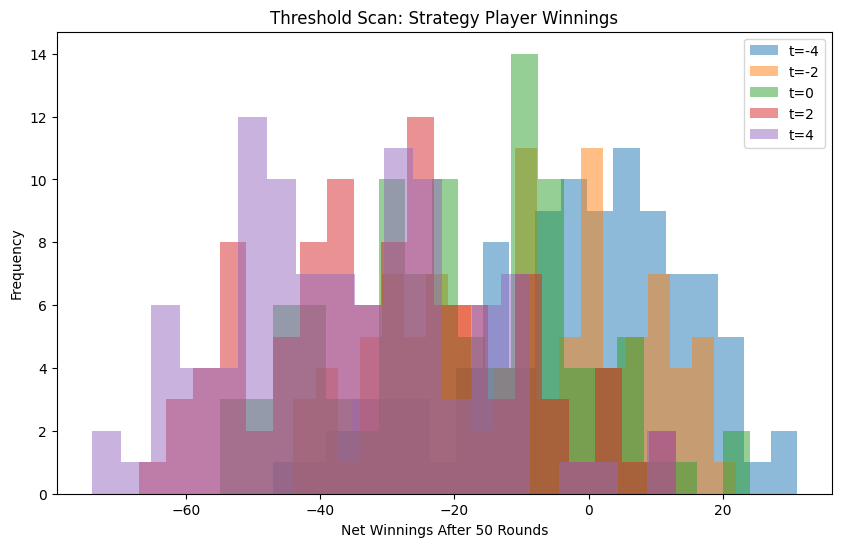

In [89]:
plt.figure(figsize=(10,6))
for t in thresholds:
    plt.hist(results_by_threshold[t], bins=20, alpha=0.5, label=f"t={t}")

plt.legend()
plt.xlabel("Net Winnings After 50 Rounds")
plt.ylabel("Frequency")
plt.title("Threshold Scan: Strategy Player Winnings")
plt.show()

Used AI and help of Lecture to figure out what output should look like

10. Create a new strategy based on web searches or your own ideas. Demonstrate that the new strategy will result in increased or decreased winnings. 

In [90]:
class HybridStrategyPlayer(PlayerBase):
    def __init__(self, name, chips, count_threshold=-2, hit_until=17):
        super().__init__(name, chips)
        self.count_threshold = count_threshold
        self.hit_until = hit_until

    def card_count_value(self, card):
        val = card.value()
        if val in [2,3,4,5,6]:
            return 1
        elif val in [7,8,9]:
            return 0
        else:
            return -1

## Use card counting strategy like before
    def play_hand(self, down_card, up_cards, seen_cards):
        all_seen = [down_card] + up_cards + seen_cards
        count = sum(self.card_count_value(c) for c in all_seen)

        if count <= self.count_threshold:
            return True 
        
## Go back to basic blackjack logic if threshold not met
        hand_value = calc_hand_value([down_card] + up_cards)
        return hand_value < self.hit_until

In [91]:
n_games = 100
final_hybrid = []

for _ in range(n_games):
    game = Game()
    game.level = Game.SILENT

    hybrid_player = HybridStrategyPlayer("Hybrid", starting_chips)
    game.add_player(hybrid_player)

    for i in range(3):
        game.add_player(DealerLikePlayer(f"DealerLike{i}", starting_chips))
    game.add_player(DealerLikePlayer("Dealer", 1000))

    game.play_game(50)
    final_hybrid.append(hybrid_player.chips() - starting_chips)

print("Hybrid Avg:", np.mean(final_hybrid))
print("Hybrid Std Dev:", np.std(final_hybrid))
print("Hybrid Win Prob:", np.mean(np.array(final_hybrid) > 0))

Hybrid Avg: -20.7
Hybrid Std Dev: 16.372843369433422
Hybrid Win Prob: 0.15


Used a combination of the card counting strategy as well as traditional blackjack logic of calculating hand values, let players hit/stay, apply bust rules, compare against dealer, and update chips.